# MMLU Cosmic Graph Analysis (10 Models x 10 Variants)

This notebook analyzes one precomputed cosmic graph built from the full 100-representation matrix:
- data/scalability_all_100/mmlu_cosmic_fit_summary.json
- data/scalability_all_100/mmlu_cosmic_weighted_adjacency.npz

It reproduces the same core story as the single-model notebook, but for the fused 10x10 case:
1. silhouette sweep across k
2. region interpretation from cluster composition
3. topology vs subject label visualization
4. model accuracy by topological region

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

try:
    import umap
except ImportError as exc:
    raise ImportError("Please install umap-learn: uv pip install umap-learn") from exc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path("data")
RUN_DIR = DATA_DIR / "scalability_all_100"
SUMMARY_PATH = RUN_DIR / "mmlu_cosmic_fit_summary.json"
ADJ_PATH = RUN_DIR / "mmlu_cosmic_weighted_adjacency.npz"
MMLU_CACHE = DATA_DIR / "mmlu_questions.csv"

K_RANGE = list(range(2, 21))
RANDOM_STATE = 42
N_INIT = 10
SUBSAMPLE_TARGET = 5000
SUBSAMPLE_SEED = 42

print(f"Summary path: {SUMMARY_PATH}")
print(f"Adjacency path: {ADJ_PATH}")

Summary path: data/scalability_all_100/mmlu_cosmic_fit_summary.json
Adjacency path: data/scalability_all_100/mmlu_cosmic_weighted_adjacency.npz


---
## Step 1: Load the Precomputed Cosmic Graph

In [2]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Missing summary file: {SUMMARY_PATH}")
if not ADJ_PATH.exists():
    raise FileNotFoundError(f"Missing adjacency file: {ADJ_PATH}")

with SUMMARY_PATH.open("r", encoding="utf-8") as f:
    summary = json.load(f)

with np.load(ADJ_PATH) as z:
    if "weighted_adjacency" in z.files:
        W = z["weighted_adjacency"]
    elif len(z.files) == 1:
        W = z[z.files[0]]
    else:
        raise ValueError(f"Unexpected keys in adjacency npz: {z.files}")

W = np.asarray(W, dtype=np.float64)
if W.ndim != 2 or W.shape[0] != W.shape[1]:
    raise ValueError(f"Adjacency must be square; got shape {W.shape}")

W = np.nan_to_num(W, nan=0.0, posinf=0.0, neginf=0.0)
W = 0.5 * (W + W.T)
W = np.clip(W, 0.0, 1.0)
np.fill_diagonal(W, 1.0)

print("Loaded cosmic graph run")
print(f"Created at: {summary.get('created_at')}")
print(f"Representations fused: {summary.get('fit', {}).get('representations_fused')}")
print(f"Total ball maps: {summary.get('fit', {}).get('total_ball_maps')}")
print(f"Resolved threshold: {summary.get('fit', {}).get('resolved_threshold')}")
print(f"Adjacency shape: {W.shape}")

artifacts = summary.get("artifacts", [])
print(f"Artifact count in summary: {len(artifacts)}")
if len(artifacts) > 0:
    print("First 10 artifacts:")
    for a in artifacts[:10]:
        print(" -", a)

Loaded cosmic graph run
Created at: 2026-04-02T11:44:26.567296+00:00
Representations fused: 100
Total ball maps: 10500
Resolved threshold: 0.0
Adjacency shape: (4970, 4970)
Artifact count in summary: 100
First 10 artifacts:
 - BAAI/bge-base-en-v1.5::v01
 - BAAI/bge-base-en-v1.5::v02
 - BAAI/bge-base-en-v1.5::v03
 - BAAI/bge-base-en-v1.5::v04
 - BAAI/bge-base-en-v1.5::v05
 - BAAI/bge-base-en-v1.5::v06
 - BAAI/bge-base-en-v1.5::v07
 - BAAI/bge-base-en-v1.5::v08
 - BAAI/bge-base-en-v1.5::v09
 - BAAI/bge-base-en-v1.5::v10


In [3]:
def build_subsample(df_mmlu: pd.DataFrame, n_subsample: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    indices = []

    for subj in df_mmlu["subject"].unique():
        subj_idx = df_mmlu.index[df_mmlu["subject"] == subj].tolist()
        n_take = max(10, int(n_subsample * len(subj_idx) / len(df_mmlu)))
        n_take = min(n_take, len(subj_idx))
        chosen = rng.choice(subj_idx, size=n_take, replace=False)
        indices.extend(chosen.tolist())

    if len(indices) > n_subsample:
        indices = sorted(rng.choice(indices, size=n_subsample, replace=False))
    else:
        indices = sorted(indices)

    return df_mmlu.iloc[indices].reset_index(drop=True)

if not MMLU_CACHE.exists():
    raise FileNotFoundError(f"Missing dataset cache: {MMLU_CACHE}")

df_mmlu = pd.read_csv(MMLU_CACHE)
df_sub = build_subsample(df_mmlu, n_subsample=SUBSAMPLE_TARGET, seed=SUBSAMPLE_SEED)

subject_codes_full = pd.Categorical(df_mmlu["subject"]).codes
subject_codes_sub = pd.Categorical(df_sub["subject"]).codes

run_rows = int(summary.get("metadata_index", {}).get("rows", W.shape[0]))
run_mode = summary.get("metadata_index", {}).get("run_mode", "subsample")

if run_rows == len(df_sub):
    subject_codes = subject_codes_sub
    analysis_frame = df_sub.copy()
elif run_rows == len(df_mmlu):
    subject_codes = subject_codes_full
    analysis_frame = df_mmlu.copy()
else:
    raise RuntimeError(
        f"Row mismatch: run rows={run_rows}, subsample rows={len(df_sub)}, full rows={len(df_mmlu)}"
    )

if W.shape[0] != len(subject_codes):
    raise RuntimeError(f"Adjacency rows {W.shape[0]} do not match label rows {len(subject_codes)}")

print(f"Run mode: {run_mode}")
print(f"Rows used for analysis: {len(analysis_frame):,}")
print(f"Subjects represented: {analysis_frame['subject'].nunique()}")

Run mode: subsample
Rows used for analysis: 4,970
Subjects represented: 57


In [4]:
dist_matrix = 1.0 - W
np.fill_diagonal(dist_matrix, 0.0)

silhouette_scores = []
labels_by_k = {}

print("Silhouette sweep:")
for k in K_RANGE:
    sc = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        random_state=RANDOM_STATE,
        n_init=N_INIT,
    )
    labels_k = sc.fit_predict(W)
    sil_k = silhouette_score(dist_matrix, labels_k, metric="precomputed")
    silhouette_scores.append(float(sil_k))
    labels_by_k[k] = labels_k
    print(f"  k={k:2d}  silhouette={sil_k:.5f}")

best_idx = int(np.argmax(silhouette_scores))
best_k = K_RANGE[best_idx]
best_score = float(silhouette_scores[best_idx])
labels = labels_by_k[best_k]
analysis_frame["cluster"] = labels

ari_subject = adjusted_rand_score(subject_codes, labels)
nmi_subject = normalized_mutual_info_score(subject_codes, labels)

print("\nBest silhouette result")
print(f"Best k: {best_k}")
print(f"Best silhouette: {best_score:.5f}")
print(f"ARI(subject vs topology): {ari_subject:.4f}")
print(f"NMI(subject vs topology): {nmi_subject:.4f}")

cluster_sizes = np.bincount(labels)
print(f"Cluster sizes: {cluster_sizes.tolist()}")

Silhouette sweep:
  k= 2  silhouette=0.01246
  k= 3  silhouette=0.01255
  k= 4  silhouette=0.01304
  k= 5  silhouette=0.01366
  k= 6  silhouette=0.01387
  k= 7  silhouette=0.01421
  k= 8  silhouette=0.01427
  k= 9  silhouette=0.01466
  k=10  silhouette=0.01491
  k=11  silhouette=0.01487
  k=12  silhouette=0.01501
  k=13  silhouette=0.01567
  k=14  silhouette=0.01613
  k=15  silhouette=0.01627
  k=16  silhouette=0.00893
  k=17  silhouette=0.00907
  k=18  silhouette=0.00921
  k=19  silhouette=0.00946
  k=20  silhouette=0.00961

Best silhouette result
Best k: 15
Best silhouette: 0.01627
ARI(subject vs topology): 0.2079
NMI(subject vs topology): 0.4704
Cluster sizes: [421, 237, 209, 964, 226, 637, 5, 387, 318, 407, 339, 257, 7, 459, 97]


---
## Step 2: Interpret the Regions

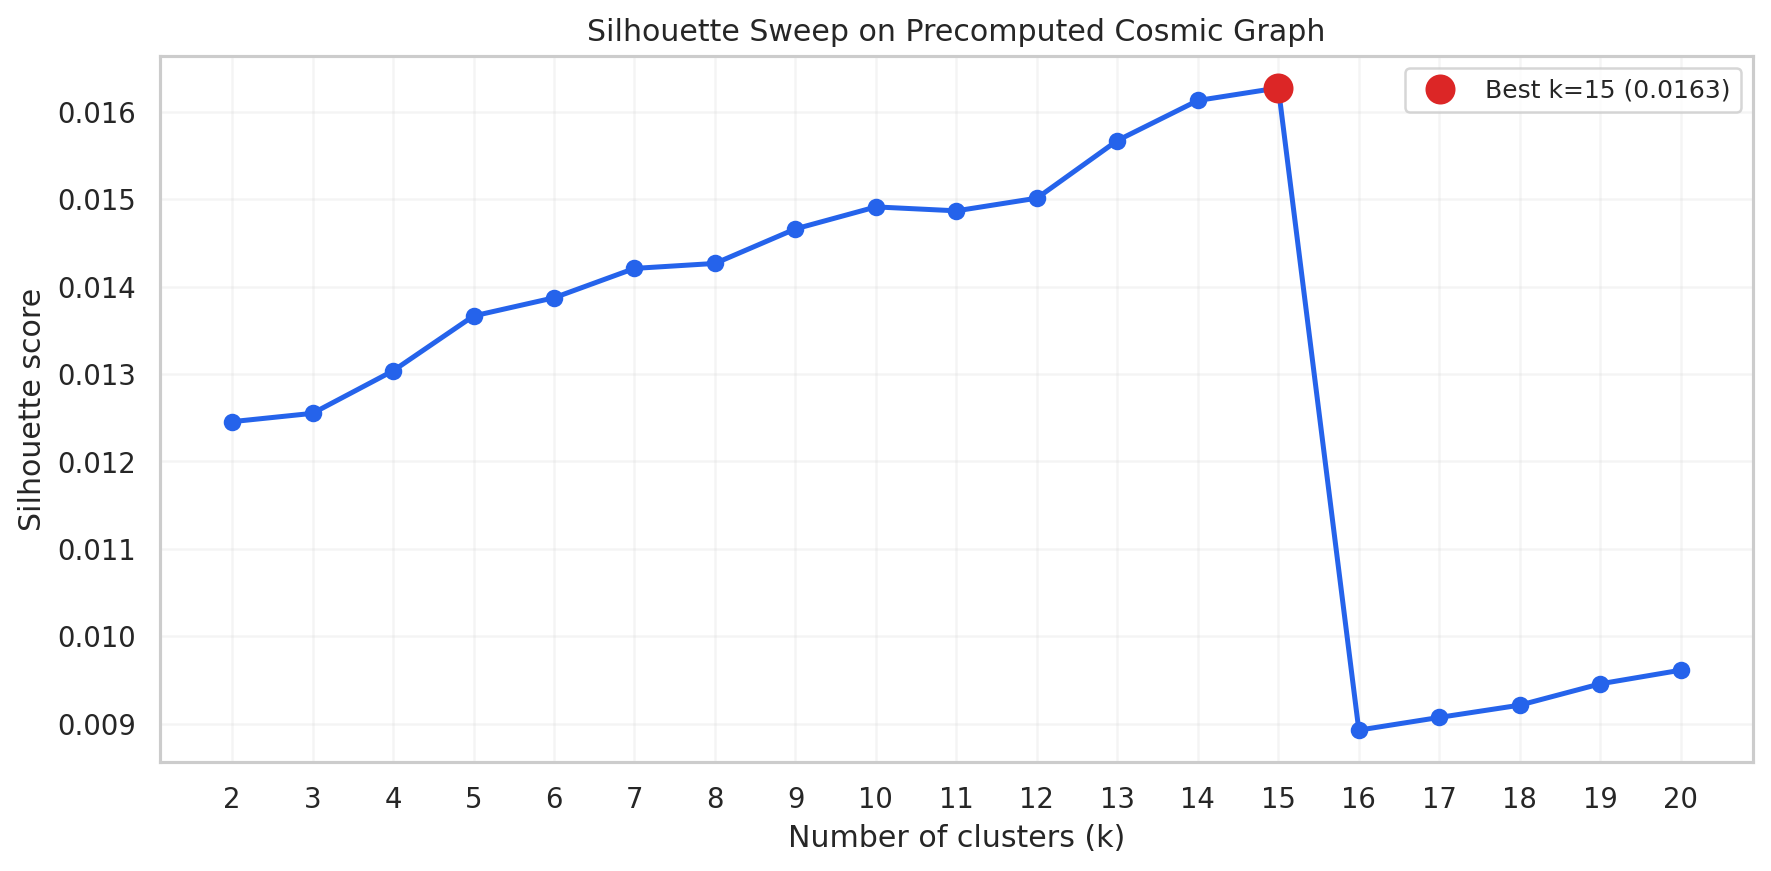

Topological region interpretation (data-driven)
 region  size  subjects_spanned           dominant_subject  dominant_share_pct                                                                                   top3_subjects
      0   421                32         conceptual_physics                12.4                   conceptual_physics (52); high_school_chemistry (52); high_school_physics (43)
      1   237                17     elementary_mathematics                32.5                elementary_mathematics (77); high_school_mathematics (69); abstract_algebra (21)
      2   209                 6  high_school_world_history                38.3  high_school_world_history (80); high_school_us_history (72); high_school_european_history (52)
      3   964                51    professional_psychology                16.2                   professional_psychology (156); high_school_psychology (121); human_aging (50)
      4   226                 2           professional_law                99.

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white", dpi=180)
ax.plot(K_RANGE, silhouette_scores, "o-", color="#2563eb", linewidth=2, markersize=6)
ax.plot(best_k, best_score, "o", color="#dc2626", markersize=11, label=f"Best k={best_k} ({best_score:.4f})")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Sweep on Precomputed Cosmic Graph")
ax.set_xticks(K_RANGE)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Build an interpretable per-region summary table from the fused 10x10 run.
summary_rows = []
for c in range(best_k):
    block = analysis_frame[analysis_frame["cluster"] == c]
    counts = block["subject"].value_counts()
    top3 = counts.head(3)
    dominant_subject = top3.index[0]
    dominant_count = int(top3.iloc[0])
    dominant_share = 100.0 * dominant_count / max(len(block), 1)

    summary_rows.append(
        {
            "region": int(c),
            "size": int(len(block)),
            "subjects_spanned": int(block["subject"].nunique()),
            "dominant_subject": dominant_subject,
            "dominant_share_pct": round(dominant_share, 1),
            "top3_subjects": "; ".join(
                [f"{subj} ({cnt})" for subj, cnt in top3.items()]
            ),
        }
    )

region_summary_df = pd.DataFrame(summary_rows).sort_values("region").reset_index(drop=True)

print("Topological region interpretation (data-driven)")
print(region_summary_df.to_string(index=False))

print("\nInterpretation notes")
for row in region_summary_df.itertuples(index=False):
    concentration = row.dominant_share_pct
    if concentration >= 80:
        tag = "near-island"
    elif concentration >= 50:
        tag = "highly concentrated"
    elif concentration >= 25:
        tag = "mixed but biased"
    else:
        tag = "highly mixed"

    print(
        f"Region {row.region}: n={row.size}, subjects={row.subjects_spanned}, "
        f"dominant={row.dominant_subject} ({row.dominant_share_pct:.1f}%) -> {tag}"
    )

print("\nSubject/topology alignment metrics")
print(f"ARI(subject vs topology): {ari_subject:.4f}")
print(f"NMI(subject vs topology): {nmi_subject:.4f}")

---
## Step 3: Topology vs Subject Labels

/home/ec2-user/krv/pulsar/.venv/lib64/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ec2-user/krv/pulsar/.venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


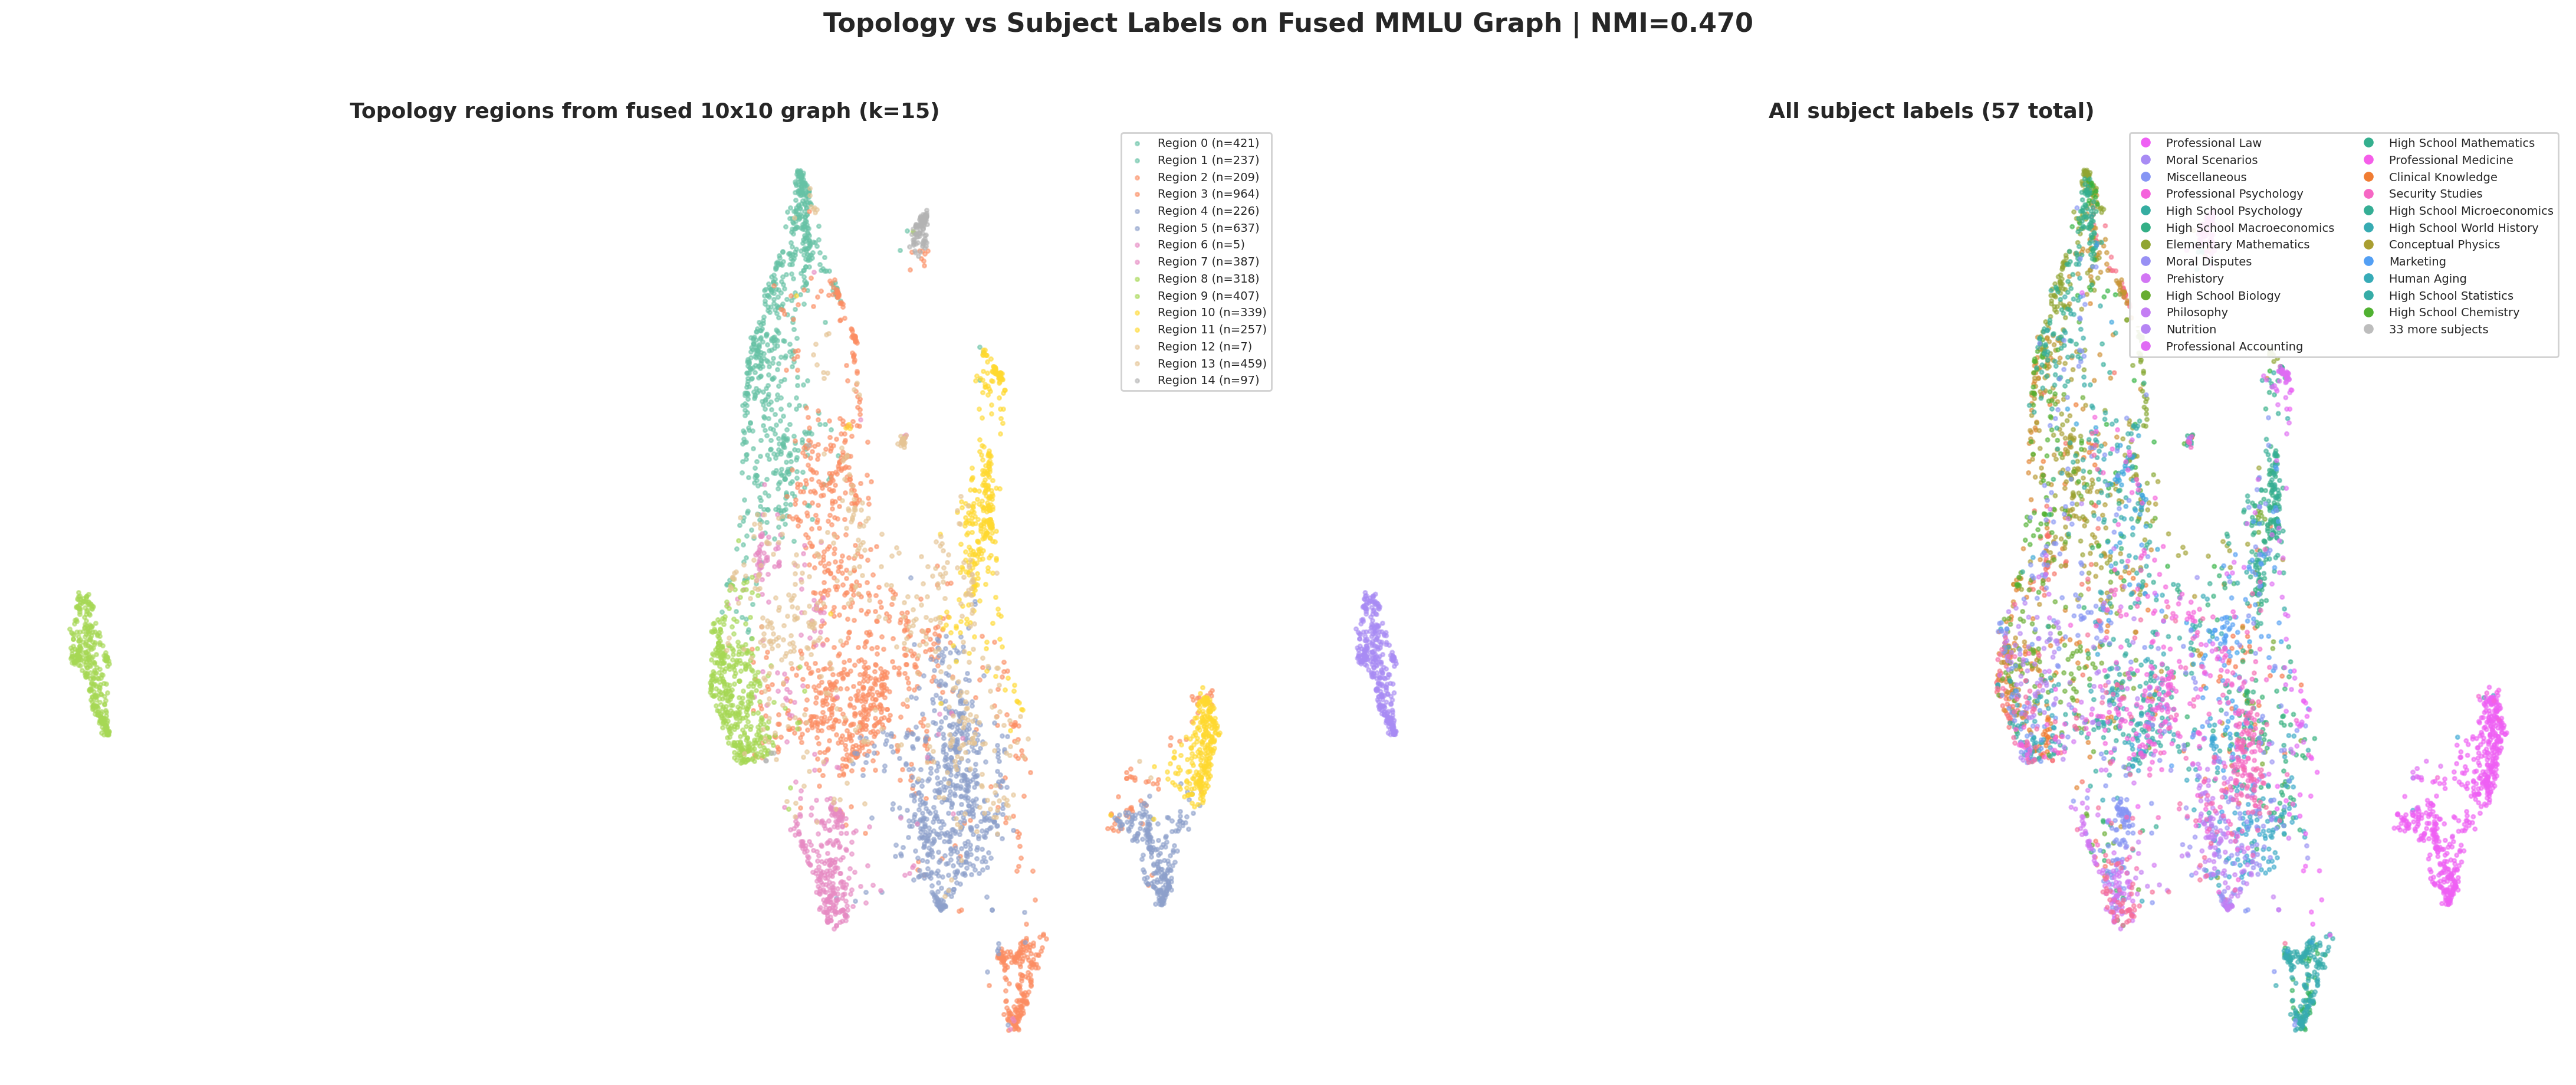

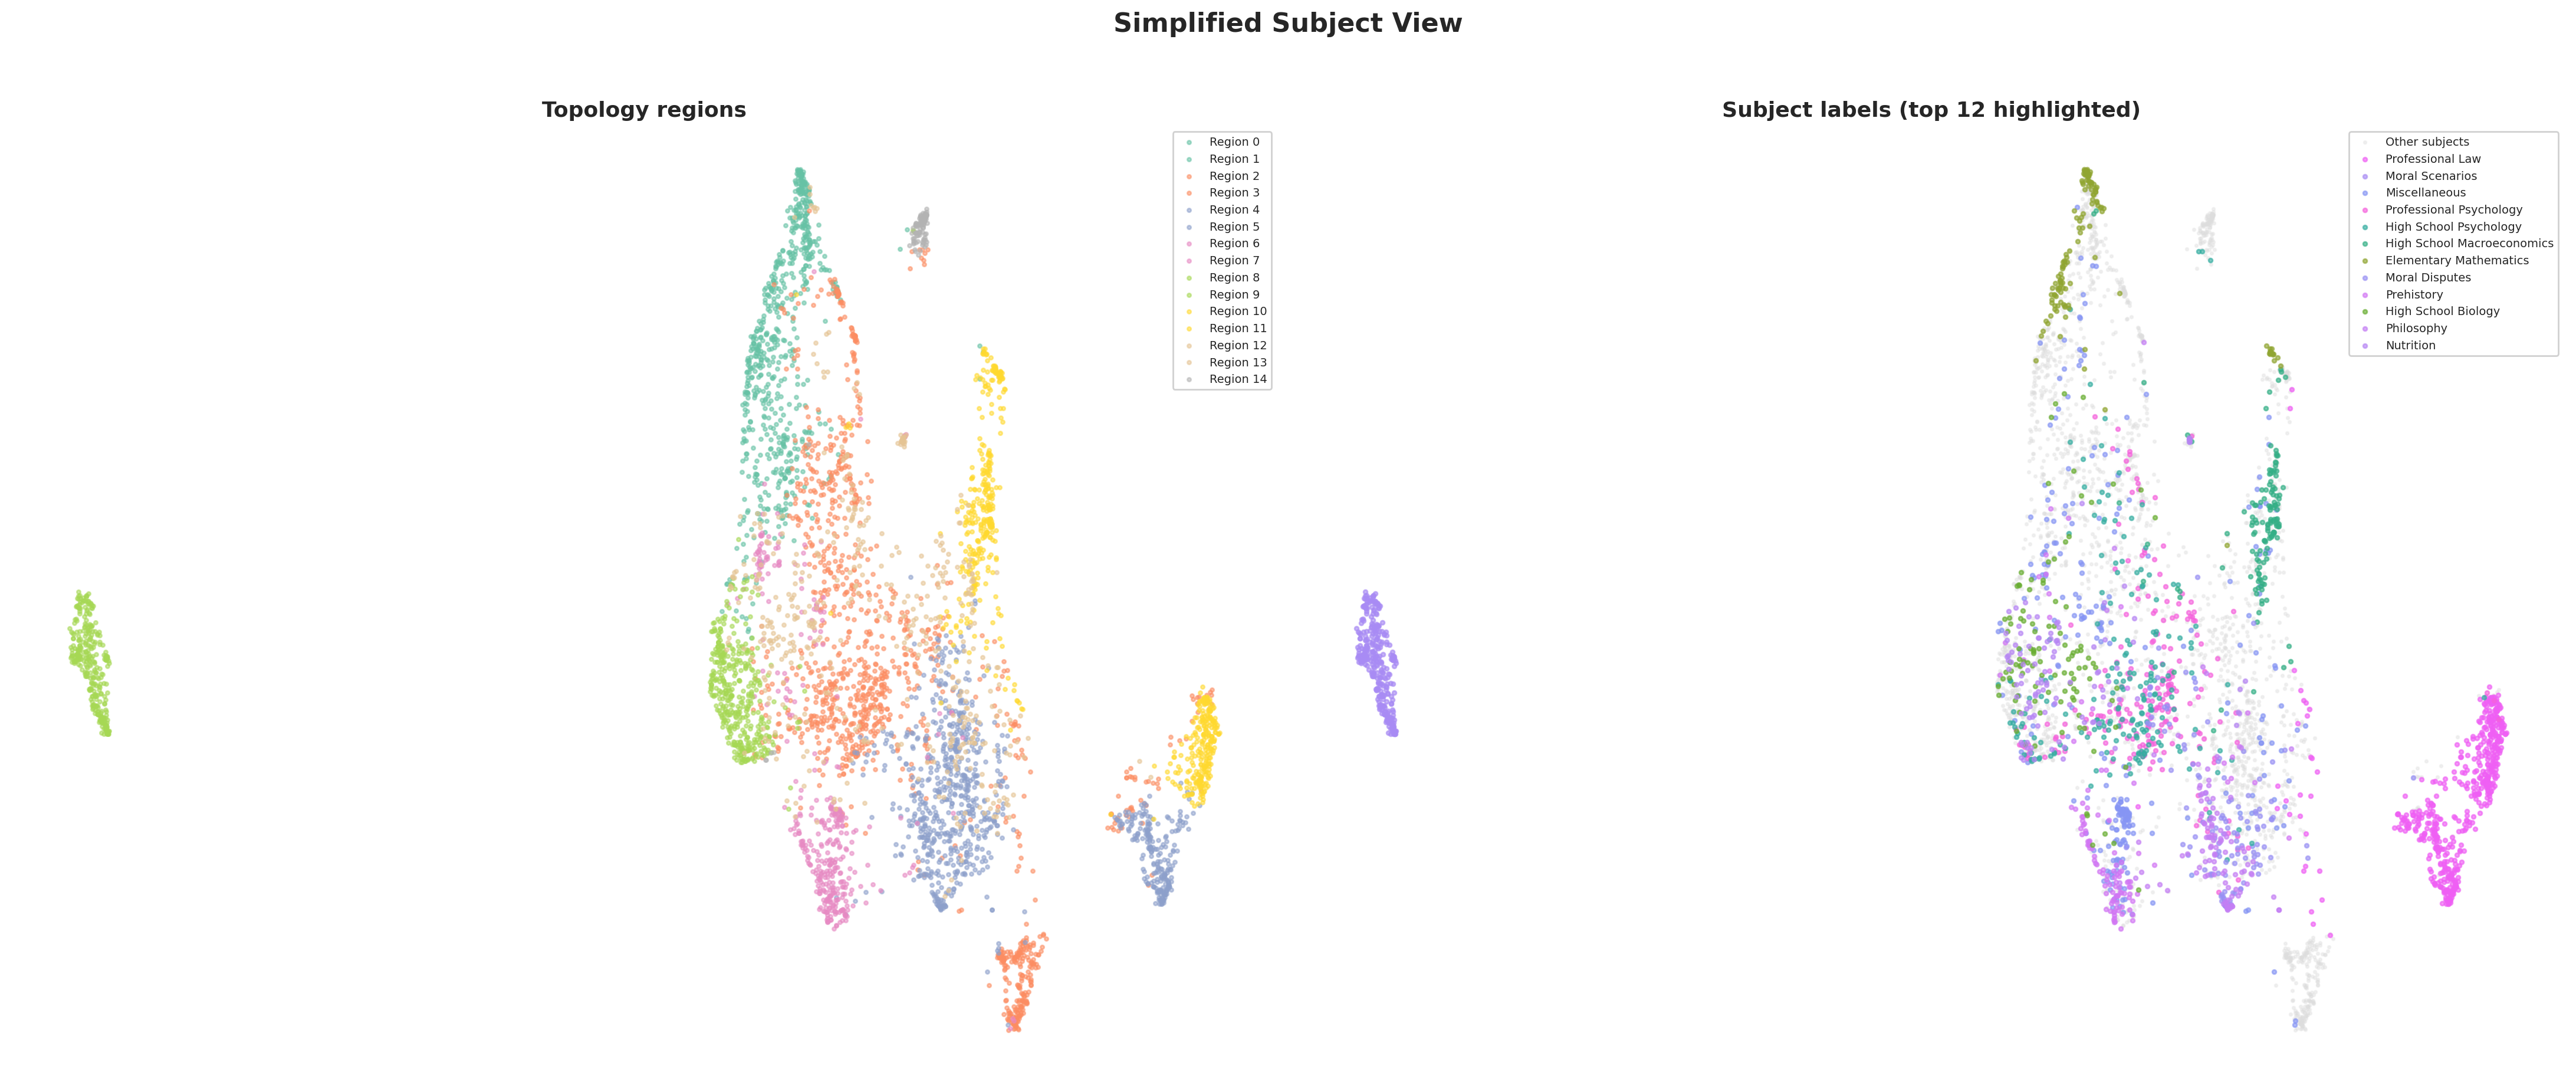

In [6]:
from matplotlib.lines import Line2D

# Build a 2D embedding from graph distances for visualization.
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="precomputed",
    random_state=RANDOM_STATE,
)
umap_2d = reducer.fit_transform(dist_matrix)

all_subjects = sorted(analysis_frame["subject"].unique())
subject_palette = sns.color_palette("husl", len(all_subjects))
subject_to_color = {s: subject_palette[i] for i, s in enumerate(all_subjects)}
subject_colors_all = [subject_to_color[s] for s in analysis_frame["subject"]]

top_subjects = analysis_frame["subject"].value_counts().head(12).index.tolist()
legend_subjects = analysis_frame["subject"].value_counts().head(24).index.tolist()

cluster_cmap = plt.cm.Set2
cluster_colors = [cluster_cmap(labels[i] / max(best_k, 1)) for i in range(len(labels))]

fig, axes = plt.subplots(1, 2, figsize=(22, 9), facecolor="white", dpi=200)

# Left: topology regions
ax = axes[0]
for c in range(best_k):
    mask = labels == c
    ax.scatter(
        umap_2d[mask, 0], umap_2d[mask, 1],
        c=[cluster_cmap(c / max(best_k, 1))], s=5, alpha=0.55, rasterized=True,
        label=f"Region {c} (n={cluster_sizes[c]})",
    )
ax.set_title(f"Topology regions from fused 10x10 graph (k={best_k})", fontsize=13, fontweight="bold")
ax.legend(fontsize=7, loc="upper right", framealpha=0.9)
ax.axis("off")

# Right: all subject labels
ax = axes[1]
ax.scatter(
    umap_2d[:, 0], umap_2d[:, 1],
    c=subject_colors_all, s=5, alpha=0.55, rasterized=True,
)
ax.set_title("All subject labels (57 total)", fontsize=13, fontweight="bold")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=subject_to_color[s],
           markersize=7, label=s.replace("_", " ").title())
    for s in legend_subjects
]
remaining_subjects = len(all_subjects) - len(legend_subjects)
if remaining_subjects > 0:
    legend_handles.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#bdbdbd",
               markersize=7, label=f"{remaining_subjects} more subjects")
    )
ax.legend(handles=legend_handles, fontsize=7, loc="upper right", framealpha=0.9, ncol=2)
ax.axis("off")

fig.suptitle(
    f"Topology vs Subject Labels on Fused MMLU Graph | NMI={nmi_subject:.3f}",
    fontsize=16,
    fontweight="bold",
    y=1.02,
 )
plt.tight_layout()
plt.show()

# Optional simplified view for readability (top-12 subjects + other)
fig, axes = plt.subplots(1, 2, figsize=(22, 9), facecolor="white", dpi=200)

ax = axes[0]
for c in range(best_k):
    mask = labels == c
    ax.scatter(
        umap_2d[mask, 0], umap_2d[mask, 1],
        c=[cluster_cmap(c / max(best_k, 1))], s=5, alpha=0.55, rasterized=True,
        label=f"Region {c}",
    )
ax.set_title("Topology regions", fontsize=13, fontweight="bold")
ax.legend(fontsize=7, loc="upper right", framealpha=0.9)
ax.axis("off")

ax = axes[1]
other_mask = ~analysis_frame["subject"].isin(top_subjects)
ax.scatter(
    umap_2d[other_mask, 0], umap_2d[other_mask, 1],
    c="#dddddd", s=3, alpha=0.35, rasterized=True, label="Other subjects",
)
for subj in top_subjects:
    mask = (analysis_frame["subject"] == subj).values
    ax.scatter(
        umap_2d[mask, 0], umap_2d[mask, 1],
        c=[subject_to_color[subj]], s=6, alpha=0.65, rasterized=True,
        label=subj.replace("_", " ").title(),
    )
ax.set_title("Subject labels (top 12 highlighted)", fontsize=13, fontweight="bold")
ax.legend(fontsize=7, loc="upper right", framealpha=0.9, ncol=1)
ax.axis("off")

fig.suptitle("Simplified Subject View", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: Accuracy per Topology Labels

/tmp/ipykernel_15548/1683833264.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


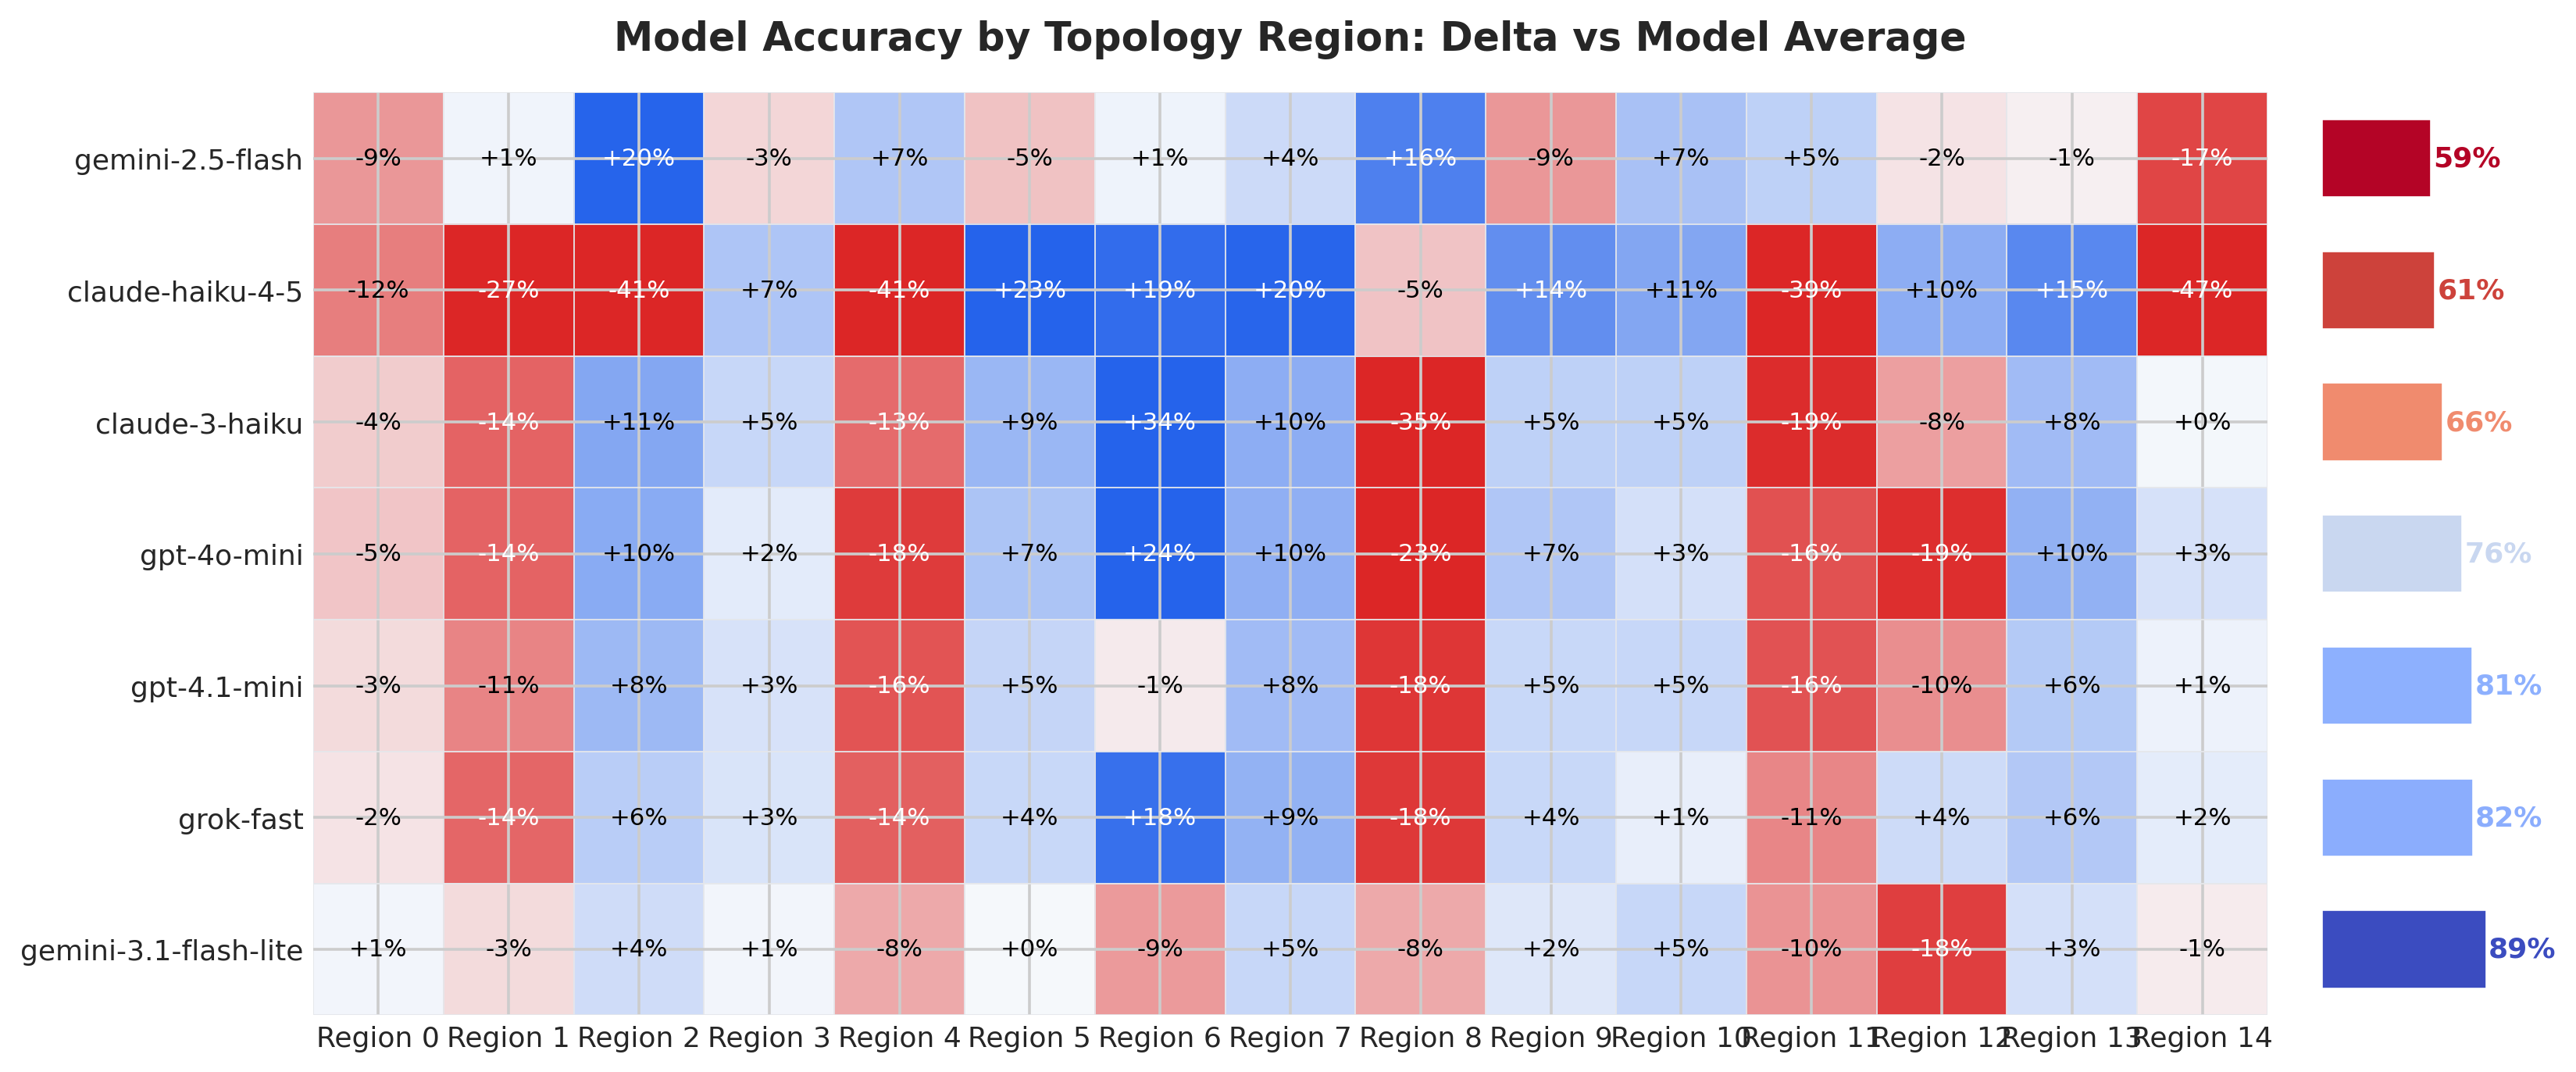

Saved outputs:
 - data/multiverse_analysis/single_run_metrics.json
 - data/multiverse_analysis/single_run_region_interpretation.csv
 - data/multiverse_analysis/single_run_subject_cluster.csv
 - data/multiverse_analysis/single_run_umap_2d.npy
 - data/multiverse_analysis/single_run_model_cluster_delta.csv


In [7]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

EVAL_PATH = DATA_DIR / "model_eval_results.csv"
OUT_DIR = DATA_DIR / "multiverse_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not EVAL_PATH.exists():
    raise FileNotFoundError(
        f"Missing {EVAL_PATH}. Generate model evaluation outputs first."
    )

eval_df = pd.read_csv(EVAL_PATH)
required_cols = {"model_name", "question_index", "is_correct"}
missing = required_cols - set(eval_df.columns)
if missing:
    raise ValueError(f"model_eval_results.csv missing columns: {sorted(missing)}")

# Join topology labels with per-question model outcomes.
cluster_map = analysis_frame[["cluster"]].reset_index().rename(columns={"index": "question_index"})
eval_df = eval_df.merge(cluster_map, on="question_index", how="inner")
if eval_df.empty:
    raise RuntimeError("No overlapping rows between eval results and cluster assignments.")

cluster_perf = (
    eval_df.groupby(["model_name", "cluster"])["is_correct"]
    .mean()
    .reset_index()
 )

pivot = cluster_perf.pivot(index="model_name", columns="cluster", values="is_correct")
pivot = pivot.reindex(columns=range(best_k))

overall = eval_df.groupby("model_name")["is_correct"].mean().sort_values(ascending=False)
pivot = pivot.loc[overall.index]

delta = pivot.sub(overall, axis=0)
model_names = delta.index.tolist()
cluster_values = delta.values

cmap = LinearSegmentedColormap.from_list(
    "clean_diverging",
    ["#dc2626", "#f8fafc", "#2563eb"],
)
vmin, vmax = -0.20, 0.20

norm = Normalize(vmin=overall.min(), vmax=overall.max())
bar_cmap = plt.get_cmap("coolwarm_r")
bar_colors = bar_cmap(norm(overall.values))

fig = plt.figure(figsize=(14, max(4.5, 0.7 * len(model_names) + 1)), facecolor="white", dpi=260)
gs = fig.add_gridspec(1, 2, width_ratios=[20, 2], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1], sharey=ax)

ax.imshow(cluster_values, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
ax.set_xticks(range(best_k))
ax.set_xticklabels([f"Region {i}" for i in range(best_k)], fontsize=10)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=10)

for i in range(len(model_names)):
    for j in range(best_k):
        val = cluster_values[i, j]
        if np.isnan(val):
            text, color = "-", "#9ca3af"
        else:
            text = f"{val:+.0%}"
            color = "black" if abs(val) < 0.12 else "white"
        ax.text(j, i, text, ha="center", va="center", fontsize=8.5, fontweight="medium", color=color)

ax.set_xticks(np.arange(-0.5, best_k, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(model_names), 1), minor=True)
ax.grid(which="minor", color="#e5e7eb", linestyle="-", linewidth=0.5)
ax.spines[:].set_visible(False)
ax.tick_params(axis="both", length=0)
ax.set_title("Model Accuracy by Topology Region: Delta vs Model Average", fontsize=14, fontweight="bold", pad=15)

y_pos = np.arange(len(model_names))
ax_bar.barh(y_pos, overall.values, height=0.6, color=bar_colors)
for i, val in enumerate(overall.values):
    ax_bar.text(val + 0.01, i, f"{val:.0%}", va="center", ha="left", fontsize=10, fontweight="bold", color=bar_colors[i])
ax_bar.set_xlim(0, 1.05)
ax_bar.invert_yaxis()
ax_bar.axis("off")

plt.tight_layout()
plt.show()

# Persist artifacts for downstream reporting.
metrics_payload = {
    "summary_path": str(SUMMARY_PATH),
    "adjacency_path": str(ADJ_PATH),
    "rows": int(len(analysis_frame)),
    "best_k": int(best_k),
    "best_silhouette": float(best_score),
    "ari_subject": float(ari_subject),
    "nmi_subject": float(nmi_subject),
    "cluster_sizes": cluster_sizes.tolist(),
    "eval_rows_after_join": int(len(eval_df)),
}

metrics_json = OUT_DIR / "single_run_metrics.json"
with metrics_json.open("w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

region_summary_df.to_csv(OUT_DIR / "single_run_region_interpretation.csv", index=False)
analysis_frame[["subject", "cluster"]].to_csv(OUT_DIR / "single_run_subject_cluster.csv", index=False)
np.save(OUT_DIR / "single_run_umap_2d.npy", umap_2d)
delta.to_csv(OUT_DIR / "single_run_model_cluster_delta.csv")

print("Saved outputs:")
print(f" - {metrics_json}")
print(f" - {OUT_DIR / 'single_run_region_interpretation.csv'}")
print(f" - {OUT_DIR / 'single_run_subject_cluster.csv'}")
print(f" - {OUT_DIR / 'single_run_umap_2d.npy'}")
print(f" - {OUT_DIR / 'single_run_model_cluster_delta.csv'}")